In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('androfuzz-mlc/balanced_augmented_dataset.csv')

print(df.shape)


(2400, 12)


In [3]:
print(df.head)

<bound method NDFrame.head of        num_files  num_permissions  num_providers  file_size_kb  num_intents  \
0     947.000000        11.000000       2.000000   3666.922852     3.000000   
1     297.000000         0.000000       0.000000    780.611328     3.000000   
2     190.000000         3.000000       0.000000   2019.749023     3.000000   
3     526.000000        12.000000       0.000000  51003.953125     3.000000   
4     580.000000         7.000000       1.000000   4270.711914     4.000000   
...          ...              ...            ...           ...          ...   
2395   54.639515        12.385607       0.012518    413.154205     1.025938   
2396  734.546936        25.504278       0.073177   3312.959961     2.589156   
2397  262.242554        11.620407       0.572780   5223.541992     4.039828   
2398  420.402069        21.912750       0.079751   2007.548584     2.175529   
2399  318.509796        13.634198       0.749799   6047.561523     4.221895   

      total_methods  

In [4]:

print(df['label'].value_counts().sort_index())

label
0    1200
1    1200
Name: count, dtype: int64


In [6]:
#print(df.head)

In [ ]:
"""import pyarrow.parquet as pq

# Load parquet file
parquet_file = "processedData/cicandmal2020-static.parquet"  # Replace with your actual parquet filename
df = pq.read_table(parquet_file).to_pandas()

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
#print(df.head())
print(df['Label'].value_counts())"""

Dataset shape: (357805, 9505)
Columns: ['F0', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26', 'F27', 'F28', 'F29', 'F30', 'F31', 'F32', 'F33', 'F34', 'F35', 'F36', 'F37', 'F38', 'F39', 'F40', 'F41', 'F42', 'F43', 'F44', 'F45', 'F46', 'F47', 'F48', 'F49', 'F50', 'F51', 'F52', 'F53', 'F54', 'F55', 'F56', 'F57', 'F58', 'F59', 'F60', 'F61', 'F62', 'F63', 'F64', 'F65', 'F66', 'F67', 'F68', 'F69', 'F70', 'F71', 'F72', 'F73', 'F74', 'F75', 'F76', 'F77', 'F78', 'F79', 'F80', 'F81', 'F82', 'F83', 'F84', 'F85', 'F86', 'F87', 'F88', 'F89', 'F90', 'F91', 'F92', 'F93', 'F94', 'F95', 'F96', 'F97', 'F98', 'F99', 'F100', 'F101', 'F102', 'F103', 'F104', 'F105', 'F106', 'F107', 'F108', 'F109', 'F110', 'F111', 'F112', 'F113', 'F114', 'F115', 'F116', 'F117', 'F118', 'F119', 'F120', 'F121', 'F122', 'F123', 'F124', 'F125', 'F126', 'F127', 'F128', 'F129', 'F130', 'F131', 'F132', 'F133'

In [2]:



# Load parquet files
benign_df = pd.read_csv("processedData/benign.csv")
mal_df = pd.read_csv("processedData/malware_binary.csv")

print("Benign shape:", benign_df.shape)
print("Malware shape:", mal_df.shape)
 
# IMPORTANT: reset column names to be identical
benign_df.columns = range(benign_df.shape[1])
mal_df.columns = range(mal_df.shape[1])


# Concatenate safely
df = pd.concat([benign_df, mal_df], axis=0, ignore_index=True)

print("Final dataset shape:", df.shape)
#print(df["label"].value_counts())

print(df.shape)


#colomn 9505 is ur lable

Benign shape: (162181, 9505)
Malware shape: (195624, 9505)
Final dataset shape: (357805, 9505)
(357805, 9505)


In [4]:
print(df.head())

                                                0     1     2     3     4     \
0  000002B63FAD4B030787F6DE4081DC1E12325026EB7DDA...    52     0     0    44   
1  00000989F3E215BA9FC3BDD5B56AF751343B540C1026BF...    71     0     0    24   
2  00000F8EE4F64324BA04356745E946152C2F43ECB63372...   688     0     0    76   
3  00001091AE8F704E461A37576EE67CCCD1F286D07C6C17...   295     0     0   134   
4  000010F33B578B4B5C33724520E38BD44485705DC1B6AD...   319     0     0    87   

   5     6     7     8     9     ...  9495  9496  9497  9498  9499  9500  \
0     3     1     0     2     1  ...     0     0     0     0     0   0.0   
1     8     0     1    11     1  ...     0     0     0     0     0   0.0   
2     7     3     4    13     3  ...     0     0     0     0     0   0.0   
3     7     3     6    14     3  ...     0     0     0     0     0   0.0   
4     4     6     6    10     1  ...     0     0     0     0     0   0.0   

   9501  9502  9503  9504  
0   0.0   0.0   0.0     0  
1   0.

In [3]:


X = df.drop(9504, axis=1).select_dtypes(include=[np.number])  # also drop hash column (1)
y = df[9504]

# Compute correlation of each feature with label
correlations = X.corrwith(y)

# Sort by absolute correlation
corr_sorted = correlations.abs().sort_values(ascending=False)

print(corr_sorted.head(20))

/home/gentlsnek/MajorProject/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/gentlsnek/MajorProject/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


50      0.747576
57      0.716959
37      0.699974
48      0.699124
58      0.683630
36      0.683147
3052    0.682764
63      0.682764
3335    0.640379
51      0.639820
66      0.634830
107     0.626421
25      0.626364
3293    0.595365
35      0.591604
26      0.583790
39      0.564001
9       0.529084
138     0.521460
8       0.510686
dtype: float64


In [4]:
TOP_N = 20

top_features = corr_sorted.head(TOP_N).index.tolist()

print("Selected feature indices:", top_features)

Selected feature indices: [50, 57, 37, 48, 58, 36, 3052, 63, 3335, 51, 66, 107, 25, 3293, 35, 26, 39, 9, 138, 8]


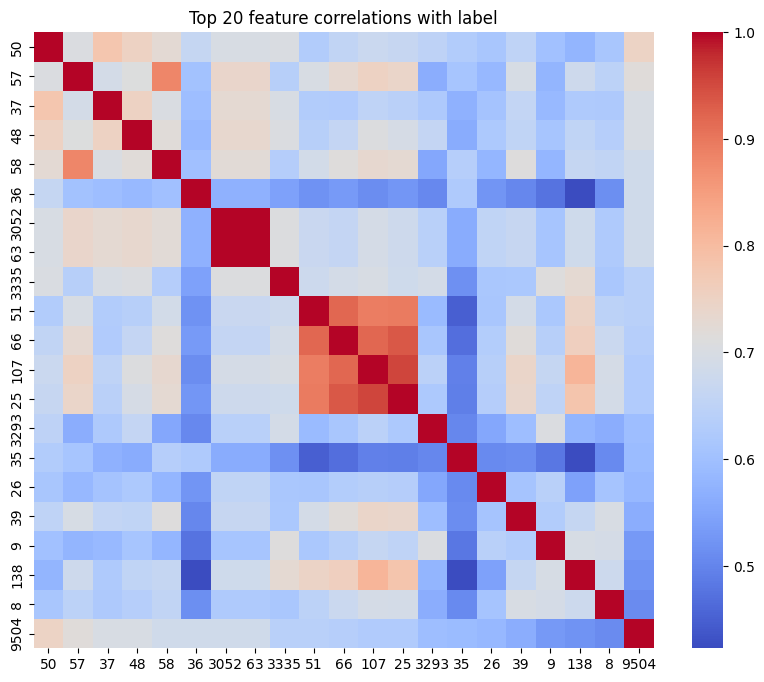

In [5]:


top20 = corr_sorted.head(20).index
corr_matrix = df[top_features + [9504]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Top 20 feature correlations with label")
plt.show()

In [6]:
X_reduced = X[top_features]

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2,random_state=42
)

model = RandomForestClassifier(
    n_estimators=200, n_jobs=-1, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", model.score(X_test, y_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9628009670071687
Confusion Matrix:
 [[31595   952]
 [ 1710 37304]]
Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96     32547
           1       0.98      0.96      0.97     39014

    accuracy                           0.96     71561
   macro avg       0.96      0.96      0.96     71561
weighted avg       0.96      0.96      0.96     71561



In [17]:
import numpy as np

y_train_shuffled = np.random.permutation(y_train)
model.fit(X_train, y_train_shuffled)
print("Accuracy with shuffled labels:", model.score(X_test, y_test))

Accuracy with shuffled labels: 0.5418454185939269


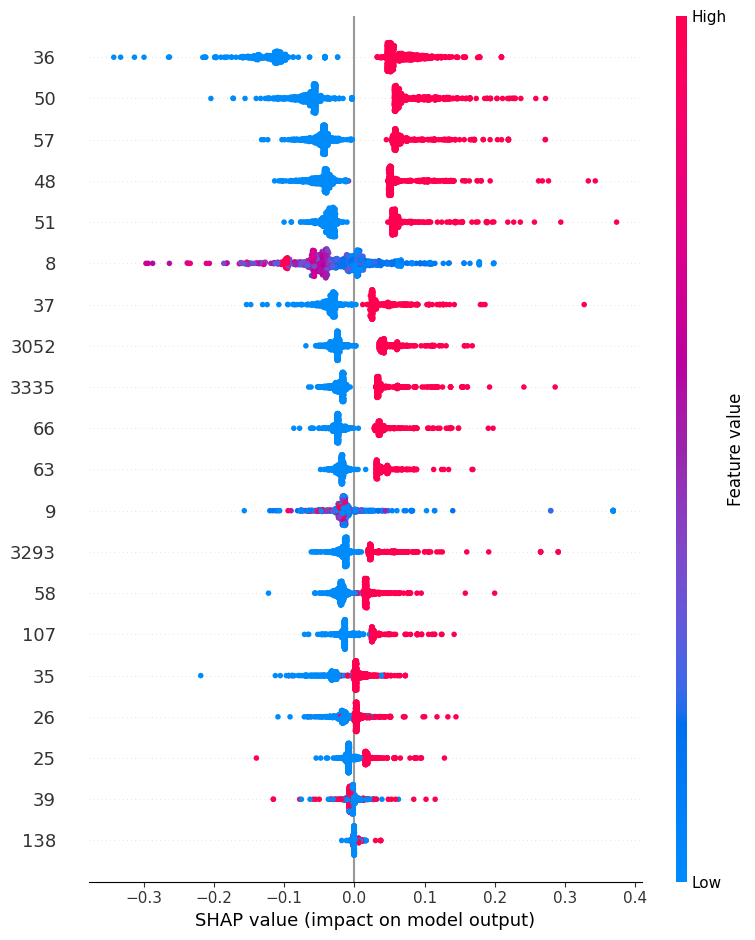

In [11]:

import shap
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# sample only 200 rows
X_sample = X_train.sample(1000)

# train a smaller RF just for SHAP
rf_shap = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_shap.fit(X_train, y_train)

explainer = shap.TreeExplainer(rf_shap)


shap_values = explainer(X_sample)  # only malware class
malicious_shap_values = shap_values [:, :, 1]

shap.summary_plot(malicious_shap_values, X_sample)


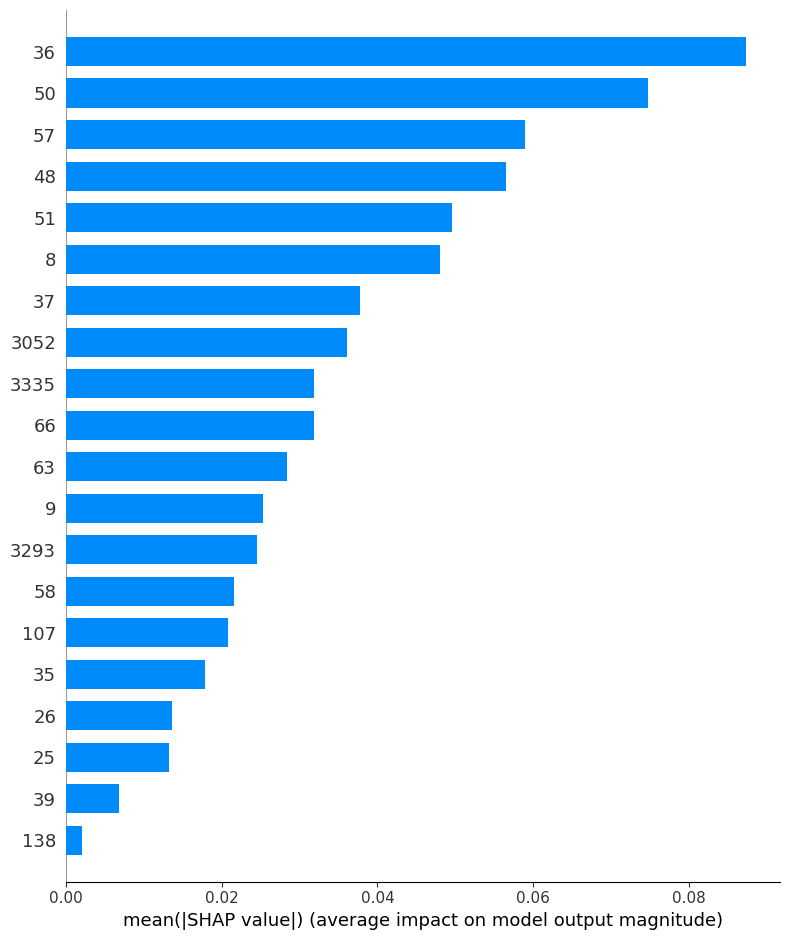

In [12]:
shap.summary_plot(shap_values[:, :, 1], X_sample, plot_type="bar")

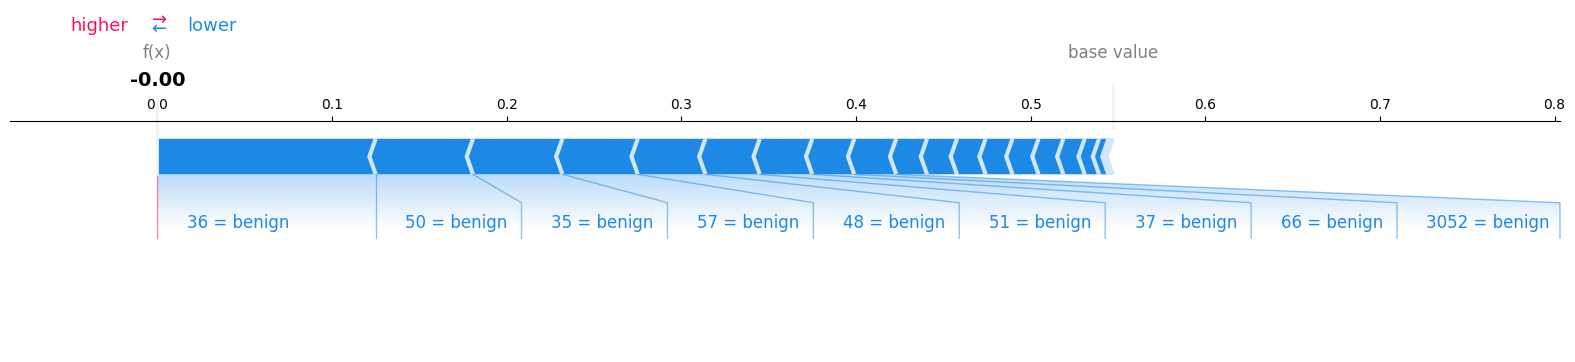

In [13]:
i = 0  # The index of the Android app you want to explain
feature_values = X_sample.iloc[i, :].map(lambda x: 'malware' if x == 1 else 'benign')
# Use .values to get the specific array for the plot
shap.force_plot(
    explainer.expected_value[1],     # The base value for 'Malicious'
    shap_values.values[i, :, 1],    # Add .values here to pass the raw array
    feature_values,        # The actual feature values
    matplotlib=True
)

In [14]:
sample = X_test.iloc[0:70]
pred = model.predict(sample)
# 2. Iterate through the predictions

explainer = shap.TreeExplainer(model)
shap_explanations = explainer(sample, check_additivity=False)

for i, app_pred in enumerate(pred):
    status = "Malware" if app_pred == 1 else "Benign"
    
    # Get the SHAP values for this specific app (class 1: Malicious)
    # We look for the highest positive contributions for Malware
    # and highest negative contributions for Benign
    current_shap_values = shap_explanations.values[i, :, 1]
    feature_names = sample.columns
    
    # Sort features by their impact (absolute SHAP value)
    top_indices = np.argsort(np.abs(current_shap_values))[-3:][::-1]
    
    reasons = []
    for idx in top_indices:
        val = current_shap_values[idx]
        feature_name = feature_names[idx]
        direction = "contributed to Malware risk" if val > 0 else "suggested Benign behavior"
        reasons.append(f"{feature_name} ({direction} by {abs(val):.4f})%")
        

    print(f"App {i}: {status} detected.")
    print(f"   Reasoning: {', '.join(reasons)}\n")

App 0: Malware detected.
   Reasoning: 57 (contributed to Malware risk by 0.0607)%, 50 (contributed to Malware risk by 0.0603)%, 51 (contributed to Malware risk by 0.0586)%

App 1: Benign detected.
   Reasoning: 36 (suggested Benign behavior by 0.1026)%, 50 (suggested Benign behavior by 0.0561)%, 37 (suggested Benign behavior by 0.0463)%

App 2: Malware detected.
   Reasoning: 57 (contributed to Malware risk by 0.0607)%, 50 (contributed to Malware risk by 0.0603)%, 51 (contributed to Malware risk by 0.0586)%

App 3: Malware detected.
   Reasoning: 57 (contributed to Malware risk by 0.1899)%, 3052 (contributed to Malware risk by 0.1661)%, 63 (contributed to Malware risk by 0.1216)%

App 4: Benign detected.
   Reasoning: 35 (suggested Benign behavior by 0.1094)%, 50 (suggested Benign behavior by 0.0739)%, 57 (suggested Benign behavior by 0.0577)%

App 5: Malware detected.
   Reasoning: 57 (contributed to Malware risk by 0.2745)%, 36 (contributed to Malware risk by 0.1243)%, 8 (contribute